In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================================
# CELL 2: Set Path and Verify
# ============================================================================

dataset_path = "data/raw/Crema"

print(f"Dataset path: {dataset_path}")
print(f"Path exists: {os.path.exists(dataset_path)}")
print(f"Current directory: {os.getcwd()}")

Dataset path: data/raw/Crema
Path exists: True
Current directory: c:\Users\cmart\OneDrive\Documents\Speech Emotion Recognition\speech_emotion_recognition


In [3]:
# ============================================================================
# CELL 3: Find Audio Files
# ============================================================================

audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
audio_files = []

for ext in audio_extensions:
    found = list(Path(dataset_path).rglob(f'*{ext}'))
    audio_files.extend(found)
    print(f"Found {len(found)} {ext} files")

print(f"\n Total: {len(audio_files)} audio files")

if len(audio_files) > 0:
    print(f"\nFirst 5 files:")
    for i, f in enumerate(audio_files[:5]):
        print(f"  {i+1}. {f.name}")
else:
    print("ERROR: No audio files found!")

Found 7442 .wav files
Found 0 .mp3 files
Found 0 .flac files
Found 0 .ogg files
Found 0 .m4a files

 Total: 7442 audio files

First 5 files:
  1. 1001_DFA_ANG_XX.wav
  2. 1001_DFA_DIS_XX.wav
  3. 1001_DFA_FEA_XX.wav
  4. 1001_DFA_HAP_XX.wav
  5. 1001_DFA_NEU_XX.wav


In [4]:
# ============================================================================
# CELL 4: Analyze Audio Files
# ============================================================================

file_properties = []

print(f"Analyzing {len(audio_files[:20])} audio files...\n")

for i, audio_file in enumerate(audio_files[:20]):
    try:
        y, sr = librosa.load(str(audio_file), sr=None)
        duration = len(y) / sr
        
        file_properties.append({
            'filename': audio_file.name,
            'sample_rate': sr,
            'duration_seconds': duration,
            'num_samples': len(y),
        })
        
        if (i + 1) % 5 == 0:
            print(f"  Analyzed {i + 1} files...")
            
    except Exception as e:
        print(f"  Error with {audio_file.name}: {str(e)[:50]}")

print(f"\nSuccessfully analyzed {len(file_properties)} files")

df_properties = pd.DataFrame(file_properties)

if len(df_properties) > 0:
    print(f"DataFrame shape: {df_properties.shape}")
    print(f"Columns: {df_properties.columns.tolist()}")
else:
    print("ERROR: df_properties is empty!")

Analyzing 20 audio files...



  Analyzed 5 files...
  Analyzed 10 files...
  Analyzed 15 files...
  Analyzed 20 files...

Successfully analyzed 20 files
DataFrame shape: (20, 4)
Columns: ['filename', 'sample_rate', 'duration_seconds', 'num_samples']


In [5]:
# ============================================================================
# CELL 5: Audio Stats
# ============================================================================

if len(df_properties) > 0:
    print("="*70)
    print("AUDIO STATISTICS")
    print("="*70)
    print(f"Sample Rates: {df_properties['sample_rate'].unique()}")
    print(f"Duration Range: {df_properties['duration_seconds'].min():.2f}s - {df_properties['duration_seconds'].max():.2f}s")
    print(f"Average Duration: {df_properties['duration_seconds'].mean():.2f}s")
    print("="*70)
else:
    print("ERROR: df_properties is empty!")

AUDIO STATISTICS
Sample Rates: [16000]
Duration Range: 1.53s - 2.64s
Average Duration: 1.93s


Loading: 1001_DFA_ANG_XX.wav


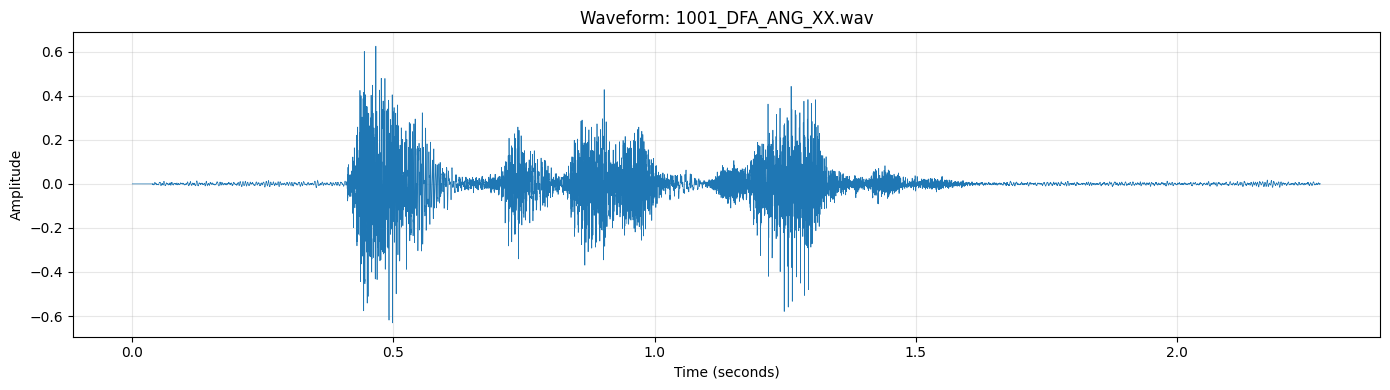

Visualization complete


In [6]:
# ============================================================================
# CELL 6: Visualize Sample Waveform
# ============================================================================

if len(audio_files) > 0:
    sample_audio = audio_files[0]
    print(f"Loading: {sample_audio.name}")
    
    try:
        y, sr = librosa.load(str(sample_audio), sr=None)
        
        fig, ax = plt.subplots(figsize=(14, 4))
        time_axis = np.arange(len(y)) / sr
        ax.plot(time_axis, y, linewidth=0.5)
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Amplitude')
        ax.set_title(f'Waveform: {sample_audio.name}')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"Visualization complete")
        
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No audio files to visualize")

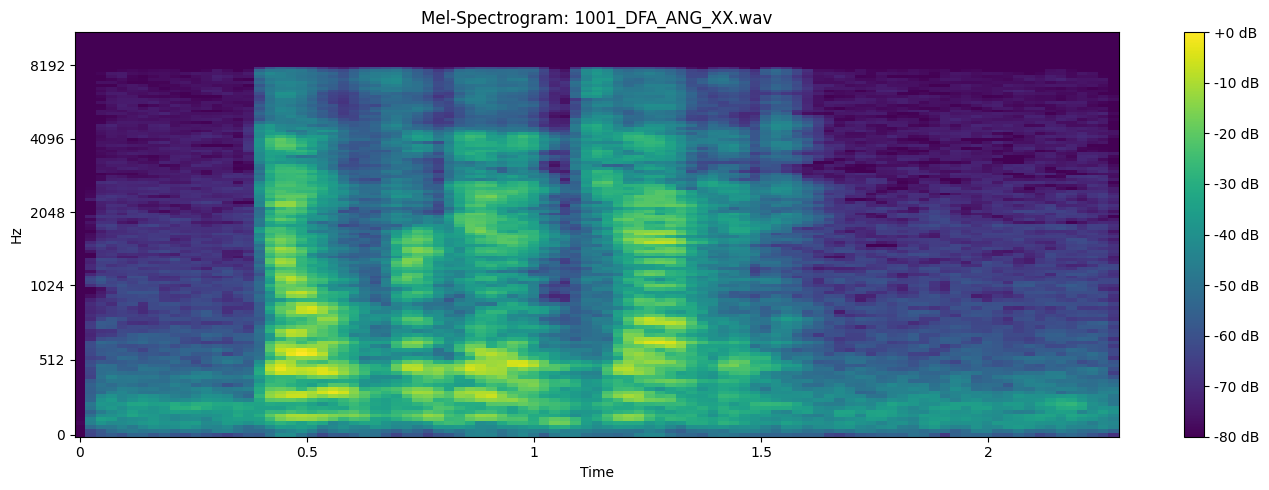

Mel-Spectrogram shape: (128, 99)


In [7]:
# ============================================================================
# CELL 7: Create Mel-Spectrogram
# ============================================================================

if len(audio_files) > 0:
    sample_audio = audio_files[0]
    
    try:
        y, sr = librosa.load(str(sample_audio), sr=22050)
        
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        plt.figure(figsize=(14, 5))
        img = librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', cmap='viridis')
        plt.colorbar(img, format='%+2.0f dB')
        plt.title(f'Mel-Spectrogram: {sample_audio.name}')
        plt.tight_layout()
        plt.show()
        
        print(f"Mel-Spectrogram shape: {S_db.shape}")
        
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No audio files")

In [8]:
# ============================================================================
# CELL 8: Extract Emotion Labels from Filenames
# ============================================================================

# CREMA-D filenames are like: 1001_DFA_ANG_XX.wav
# Format: SpeakerID_Sentence_Emotion_Intensity.wav
# Emotions: ANG (anger), DIS (disgust), FEA (fear), HAP (happy), NEU (neutral), SAD (sad)

emotion_mapping = {
    'ANG': 'anger',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

def extract_emotion(filename):
    """Extract emotion from CREMA-D filename"""
    # Format: 1001_DFA_ANG_XX.wav
    parts = filename.split('_')
    if len(parts) >= 3:
        emotion_code = parts[2]
        return emotion_mapping.get(emotion_code, 'unknown')
    return 'unknown'

# Create manifest
manifest = []
for audio_file in audio_files:
    emotion = extract_emotion(audio_file.name)
    manifest.append({
        'file_path': str(audio_file),
        'emotion': emotion,
        'filename': audio_file.name,
    })

df_manifest = pd.DataFrame(manifest)

print(f"✓ Created manifest with {len(df_manifest)} files")
print(f"\nEmotion Distribution:")
print(df_manifest['emotion'].value_counts())

✓ Created manifest with 7442 files

Emotion Distribution:
emotion
anger      1271
disgust    1271
fear       1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64


In [ ]:
# ============================================================================
# CELL 9: Summary Report
# ============================================================================

print("\n" + "="*70)
print("DATA EXPLORATION SUMMARY")
print("="*70)

print(f"\nTotal Files: {len(df_manifest)}")
print(f"Unique Emotions: {df_manifest['emotion'].nunique()}")

if len(df_properties) > 0:
    print(f"\nAudio Properties:")
    print(f"  Average Duration: {df_properties['duration_seconds'].mean():.2f}s")
    print(f"  Sample Rates: {df_properties['sample_rate'].unique()}")

print(f"\nMel-Spectrogram Settings:")
print(f"  Sample Rate: 22050 Hz")
print(f"  Mel Bands: 128")
print(f"  FFT Size: 2048")
print(f"  Hop Length: 512")

print("\nEmotion Breakdown:")
for emotion, count in df_manifest['emotion'].value_counts().items():
    pct = (count / len(df_manifest)) * 100
    print(f"  {emotion}: {count} files ({pct:.1f}%)")

print("\n" + "="*70)
print("Data Exploration Complete!")
print("="*70)


PHASE 2: DATA EXPLORATION SUMMARY

Total Files: 7442
Unique Emotions: 6

Audio Properties:
  Average Duration: 1.93s
  Sample Rates: [16000]

Mel-Spectrogram Settings:
  Sample Rate: 22050 Hz
  Mel Bands: 128
  FFT Size: 2048
  Hop Length: 512

Emotion Breakdown:
  anger: 1271 files (17.1%)
  disgust: 1271 files (17.1%)
  fear: 1271 files (17.1%)
  happy: 1271 files (17.1%)
  sad: 1271 files (17.1%)
  neutral: 1087 files (14.6%)

Data Exploration Complete!
